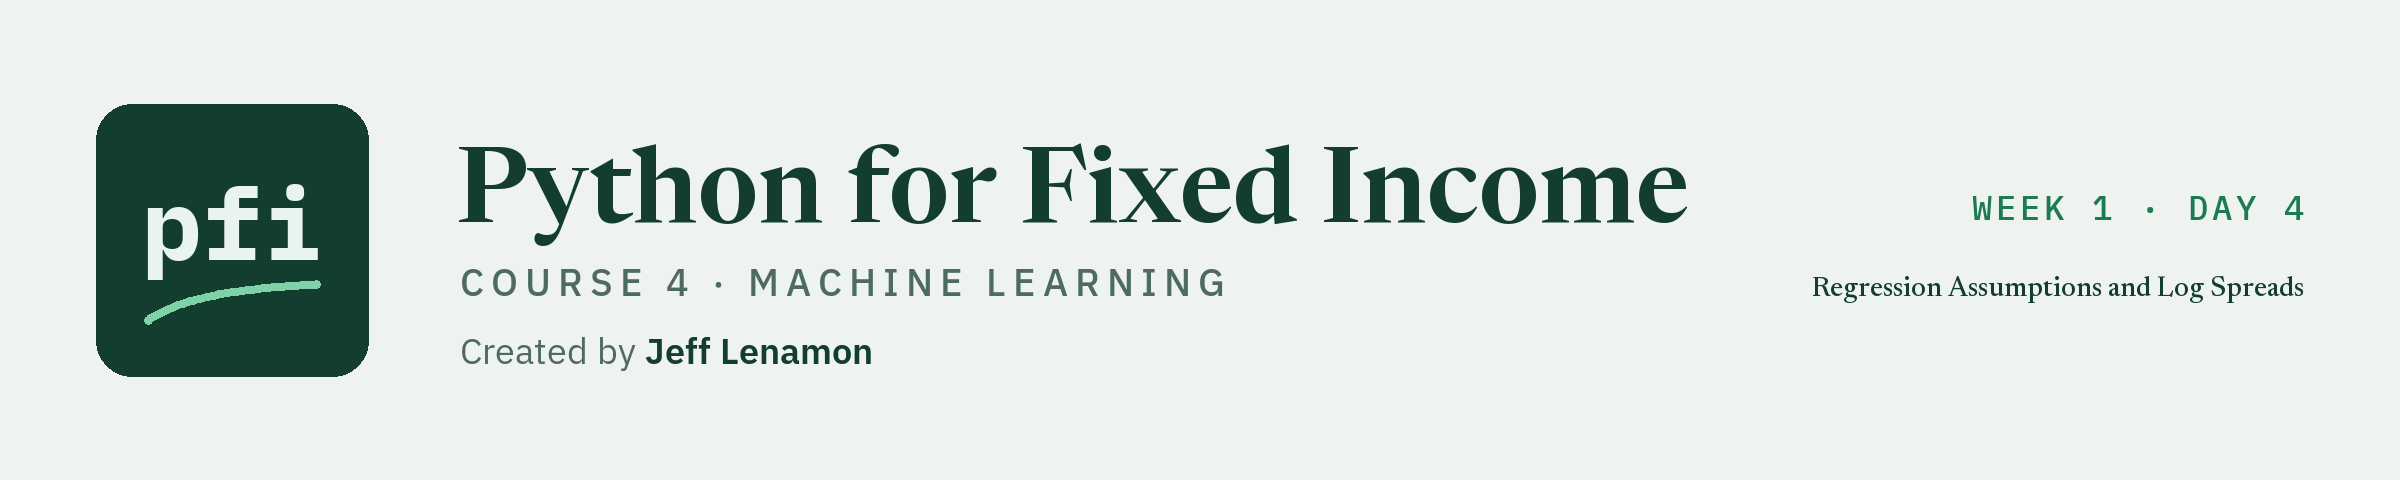

# Regression Assumptions and Log Spreads

Week 1, Day 4. Every p-value statsmodels prints rests on assumptions about the residuals. Today: check them with plots and tests, see why spreads in bp break them, move to log spreads, and report errors back in bp.

**Data:** `benchmark.csv` and `ratings.csv`, 821 bonds of invented issuers: **synthetic**, made for this course by `tools/make_holdings.py`. No real issuer, price, or spread.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course4_machine_learning/week1/day4/04_regression_assumptions_and_log_spreads.ipynb)

Yesterday statsmodels printed a standard error, a t statistic, and a p-value for every coefficient. Each of those numbers comes from a formula that assumes three things about the model's errors: the fitted values follow the right shape (linearity), the errors are about as large for a tight bond as for a wide one (constant variance), and they are roughly normal (normality). Today you check all three on the residuals, the misses the model leaves behind.

The checks fail for spreads in bp, and the reason is in the recipe that made the data. The fix, a model of the log of OAS, is the target the rest of week 1 uses.

**The data is synthetic.** The 821 bonds of `benchmark.csv` belong to invented issuers, and their spreads were generated by the course's own script, `tools/make_holdings.py`, from each bond's rating, its maturity, an effect shared by each issuer's bonds, and random noise, with six bonds made distressed. A regression on them describes that recipe, not a market.

Today you will:

1. Fit the spread model of days 2 and 3 on the training rows and look at its residuals.
2. Check linearity with a plot of residual against fitted value and a lowess line.
3. Check constant variance: the fan, and the Breusch-Pagan test.
4. Check normality: a Q-Q plot, Jarque-Bera, and Shapiro-Wilk, then put the three tests in `residual_tests`.
5. See why the bp model fans: the generator multiplies.
6. Refit on `log_oas`, check again, and read a coefficient as a percent change.
7. Go back to bp with `exp`, measure the test MAE in bp, and say what `exp` of a fitted log is.
8. Find the six distressed bonds, check the residuals with and without them, and keep them.

Q. Set up today's work folder: the thread settings, the seed, the three data files, and the module as day 3 left it.

In [1]:
# today's setup: the thread settings, the modules, the seed, the course data, and a fresh work folder
import os

# one thread for the maths libraries, so every run of the notebook gives the same last digits.
# These two lines must run before numpy, pandas, or scikit-learn is imported: if you ran another cell first,
# restart the kernel and run this cell first (in Colab: Runtime, Restart session).
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import importlib
import importlib.metadata
import platform
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

# four packages a Colab runtime or a new environment may lack: stop with the line that installs the missing one
for module_name, install_name in [("sklearn", "scikit-learn"), ("statsmodels", "statsmodels"), ("scipy", "scipy"), ("pytest", "pytest")]:
    try:
        importlib.import_module(module_name)
    except ImportError:
        raise RuntimeError(f"{install_name} is not installed. Run  !pip install {install_name}  in a new cell, "
                           "then run this cell again.") from None

import numpy as np
import pandas as pd

# the versions the saved outputs of this notebook came from (course4_machine_learning/requirements.txt)
PINNED = {"numpy": "2.5.3", "pandas": "3.0.6", "scikit-learn": "1.9.1", "statsmodels": "0.15.0", "scipy": "1.18.1", "matplotlib": "3.11.2", "pytest": "9.1.1"}
installed = {name: importlib.metadata.version(name) for name in PINNED}
print(f"Python {platform.python_version()}; " + ", ".join(f"{name} {version}" for name, version in installed.items()))
different = [name for name in PINNED if installed[name] != PINNED[name]]
if different:
    print(f"Not the course's pinned version: {', '.join(different)}. Printed numbers may differ in the last digits from the saved notebook.")

# the seed: one number for every random choice the course makes, so every run makes the same choices
SEED = 42

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "benchmark.csv").exists()

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course4_04_"))
os.chdir(work)

# 3. copy today's data files into the work folder
DATA_FILES = ["benchmark.csv", "ratings.csv", "course4_excel_reference.csv"]
for name in DATA_FILES:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Data files from {'GitHub' if on_github else 'the data folder of the course repo'}: {', '.join(DATA_FILES)}")
print(f"SEED = {SEED}")

Python 3.13.8; numpy 2.5.3, pandas 3.0.6, scikit-learn 1.9.1, statsmodels 0.15.0, scipy 1.18.1, matplotlib 3.11.2, pytest 9.1.1
Work folder: pfi_course4_04_heomg27b, in your temp folder
Data files from the data folder of the course repo: benchmark.csv, ratings.csv, course4_excel_reference.csv
SEED = 42


Q. Write `mlkit.py` and `test_mlkit.py` as they stand at the start of today: the reference version at the end of the last notebook.

In [2]:
%%writefile mlkit.py
"""mlkit: the small pieces of machine learning that scikit-learn leaves to the analyst, written down and tested.

Written day by day in Python for Fixed Income, Course 4: Machine Learning.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one, so every run gives the same numbers.
- Spreads are in basis points (bp). A model of log_oas is fitted in natural logs of bp; its errors are reported
  in bp after exp, and exp of a fitted log is a median-type value, not a mean.
- The positive class is 1 (default, bankrupt). Precision, recall, and F1 are for class 1 only.
- A row is flagged when its model probability is at least the threshold (probability >= threshold).
- Rows that fit a model, rows that choose a setting, and rows that report a result are kept apart; the split
  functions here prove it with a check that stops.
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
from numpy.typing import ArrayLike  # a list, an array, or a pandas Series


def assert_disjoint(train_index: ArrayLike, test_index: ArrayLike) -> None:
    """Stop if any row label is in both the training rows and the test rows.

    Inputs: the labels (or positions) of the rows in each part, for example X_train.index and X_test.index.
    Output: None when the parts share no label.
    Convention: a row in both parts is a test row the model has already seen, which flatters every metric.
    Raises AssertionError naming how many labels are in both parts, and ValueError if either part is empty.
    """
    # the labels of each part as sets
    train = set(np.asarray(train_index).tolist())
    test = set(np.asarray(test_index).tolist())
    if not train or not test:
        raise ValueError("train_index and test_index must both hold at least one label")
    # the labels found in both parts
    shared = train & test
    if shared:
        raise AssertionError(f"{len(shared)} row labels are in both the training and the test rows")


def _as_1d_array(values: ArrayLike, name: str) -> np.ndarray:
    """Return `values` as a 1-D float array, or raise ValueError naming the input."""
    array = np.asarray(values, dtype=float)
    if array.ndim != 1:
        raise ValueError(f"{name} must be one-dimensional, not {array.ndim}-dimensional")
    if array.size == 0:
        raise ValueError(f"{name} is empty")
    return array


def regression_metrics(y_true: ArrayLike, y_fitted: ArrayLike) -> dict[str, float]:
    """R-squared, mean absolute error, and root mean squared error of fitted values.

    Inputs: y_true and y_fitted, the same length, in the target's unit (for example oas in bp).
    Output: {"r2", "mae", "rmse"}. r2 is unitless, 1 - SS_res / SS_tot on the rows given (on test rows it can
    be negative); mae and rmse are in the target's unit. For a log_oas model, pass exp of both to get bp.
    Convention: equal to scikit-learn's r2_score, mean_absolute_error, and root_mean_squared_error.
    Excel: =RSQ(...) only for a straight line on one feature; =AVERAGE(ABS(a-b)) and =SQRT(SUMXMY2(a,b)/COUNT(a)).
    Raises ValueError if the inputs are empty, not one-dimensional, or of different lengths.
    """
    # check both inputs and that they line up row for row
    actual = _as_1d_array(y_true, "y_true")
    fitted = _as_1d_array(y_fitted, "y_fitted")
    if actual.size != fitted.size:
        raise ValueError(f"y_true has {actual.size} values and y_fitted has {fitted.size}")
    # each error in the target's unit
    errors = actual - fitted
    # R-squared: the share of the spread around the mean that the fitted values account for
    ss_res = float(np.sum(errors ** 2))
    ss_tot = float(np.sum((actual - actual.mean()) ** 2))
    r2 = 1 - ss_res / ss_tot
    # the average size of an error, and the square root of the average squared error
    mae = float(np.mean(np.abs(errors)))
    rmse = float(np.sqrt(np.mean(errors ** 2)))
    return {"r2": r2, "mae": mae, "rmse": rmse}


def adjusted_r2(r2: float, n_rows: int, n_features: int) -> float:
    """Adjusted R-squared: R-squared with a charge for each feature.

    Inputs: r2 on the training rows (unitless), n_rows the number of training rows, n_features the number of
    features not counting the intercept.
    Output: 1 - (1 - r2) x (n_rows - 1) / (n_rows - n_features - 1), unitless. An in-sample measure, so it is
    computed on training rows only.
    Excel: =1-(1-R2)*(n-1)/(n-k-1)
    Raises ValueError if n_features is negative or n_rows is not above n_features + 1.
    """
    # the formula needs at least one degree of freedom left after the features and the intercept
    if n_features < 0:
        raise ValueError(f"n_features must be 0 or more, not {n_features}")
    if n_rows <= n_features + 1:
        raise ValueError(f"n_rows ({n_rows}) must be greater than n_features + 1 ({n_features + 1})")
    # scale the unexplained share by the ratio of degrees of freedom
    return 1 - (1 - r2) * (n_rows - 1) / (n_rows - n_features - 1)


def rating_dummies(ratings: pd.Series, levels: list[str], reference: str) -> pd.DataFrame:
    """One indicator column per rating level except the reference level, which the intercept stands for.

    Inputs: ratings, one text rating per bond (for example "BBB+"); levels, every allowed level in the order the
    columns should follow (the rating column of ratings.csv, known in advance, not learned from the data);
    reference, the level left out.
    Output: a DataFrame with the same index, one float column (0.0 or 1.0) per level except reference, named
    rating_<level>, in the order of levels. A coefficient on rating_BB is then the difference from a bond rated
    `reference`, other features fixed.
    Convention: floats, not booleans, so every library and an Excel formula read the same 0.0 and 1.0. The
    reference is named by the caller, never chosen by alphabetical order.
    Raises ValueError if ratings is empty, reference is not in levels, or a rating is not in levels.
    """
    # check the inputs before building anything
    if len(ratings) == 0:
        raise ValueError("ratings is empty")
    if reference not in levels:
        raise ValueError(f"reference {reference!r} is not one of the levels")
    unknown = sorted(set(ratings) - set(levels))
    if unknown:
        raise ValueError(f"ratings not in levels: {unknown}")
    # one column per level, 1.0 where the bond has that rating
    columns = {f"rating_{level}": (ratings == level).astype(float) for level in levels if level != reference}
    return pd.DataFrame(columns, index=ratings.index)


def vif_table(X: pd.DataFrame) -> pd.Series:
    """Variance inflation factor of each feature: how much its coefficient's variance grows from the overlap with
    the other features.

    Input: X, the features as numeric columns (no constant column; one is added inside).
    Output: a Series named vif, one value per column, sorted from highest to lowest. VIF_j = 1 / (1 - R2_j),
    where R2_j is the R-squared of column j regressed on a constant and every other column. 1 means no overlap;
    above 5 is called high and above 10 very high, as conventions. A column that is an exact copy (or exact
    combination) of others has R2_j = 1 and VIF infinity.
    Convention: equal to statsmodels' variance_inflation_factor on X with a constant added.
    Excel: =1/(1-INDEX(LINEST(xj, other columns, TRUE, TRUE), 3, 1))
    Raises ValueError if X has fewer than two columns or fewer rows than columns plus two.
    """
    # check there is something to regress on, and enough rows to do it
    if X.shape[1] < 2:
        raise ValueError(f"X needs at least two columns, not {X.shape[1]}")
    if X.shape[0] < X.shape[1] + 2:
        raise ValueError(f"X has {X.shape[0]} rows, too few for {X.shape[1]} columns")
    values = X.to_numpy(dtype=float)
    result = {}
    for j, name in enumerate(X.columns):
        # column j is the target; a constant and the other columns are the features
        target = values[:, j]
        others = np.column_stack([np.ones(len(values)), np.delete(values, j, axis=1)])
        # least squares fit and its R-squared
        coefficients, *_ = np.linalg.lstsq(others, target, rcond=None)
        ss_res = float(np.sum((target - others @ coefficients) ** 2))
        ss_tot = float(np.sum((target - target.mean()) ** 2))
        r2 = 1 - ss_res / ss_tot
        # an exact combination of the others leaves no residual (R-squared 1 to the last digit): the VIF is infinite
        result[name] = np.inf if r2 >= 1 else 1 / (1 - r2)
    return pd.Series(result, name="vif").sort_values(ascending=False)

Writing mlkit.py


In [3]:
%%writefile test_mlkit.py
"""Tests for mlkit.py.

Expected values come from Excel (course4_excel_reference.csv in this folder), from scikit-learn or statsmodels on
the same inputs, or from small examples worked by hand. No test touches the network.
Run from this folder with:  python -m pytest
"""
from pathlib import Path

import numpy as np
import pandas as pd
import pytest
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

import mlkit

HERE = Path(__file__).resolve().parent
SEED = 42


def read_bench() -> pd.DataFrame:
    """The 821 synthetic benchmark bonds joined to their rating score, with log_oas (natural log of bp)."""
    bench = pd.read_csv(HERE / "benchmark.csv")
    ratings = pd.read_csv(HERE / "ratings.csv")
    bench = bench.merge(ratings[["rating", "score"]], on="rating", how="left", validate="many_to_one")
    bench["log_oas"] = np.log(bench["oas"])
    return bench


def excel(case_id: str) -> float:
    """One value computed by Excel, looked up by its case_id (model:quantity)."""
    reference = pd.read_csv(HERE / "course4_excel_reference.csv", float_precision="round_trip")
    return float(reference.set_index("case_id").loc[case_id, "excel_value"])


def test_assert_disjoint_passes():
    mlkit.assert_disjoint([0, 1, 2], [3, 4])


def test_assert_disjoint_raises_with_count():
    with pytest.raises(AssertionError, match="2 row labels"):
        mlkit.assert_disjoint([0, 1, 2, 3], [2, 3, 4])


def test_regression_metrics_hand_values():
    # errors 10, -10, 30 bp around a mean of 200 bp
    metrics = mlkit.regression_metrics([100.0, 200.0, 300.0], [110.0, 190.0, 330.0])
    assert metrics["mae"] == pytest.approx(50 / 3, abs=1e-12)
    assert metrics["rmse"] == pytest.approx(np.sqrt(1100 / 3), abs=1e-12)
    # SS_res 1,100 over SS_tot 20,000
    assert metrics["r2"] == pytest.approx(1 - 1100 / 20000, abs=1e-12)


def test_regression_metrics_match_sklearn():
    bench = read_bench()
    slope, intercept = np.polyfit(bench["score"], bench["oas"], 1)
    fitted = intercept + slope * bench["score"]
    metrics = mlkit.regression_metrics(bench["oas"], fitted)
    assert metrics["r2"] == pytest.approx(r2_score(bench["oas"], fitted), abs=1e-12)
    assert metrics["mae"] == pytest.approx(mean_absolute_error(bench["oas"], fitted), abs=1e-12)
    assert metrics["rmse"] == pytest.approx(root_mean_squared_error(bench["oas"], fitted), abs=1e-12)
    with pytest.raises(ValueError):
        mlkit.regression_metrics([1.0, 2.0], [1.0])


def test_slope_matches_excel_reference():
    bench = read_bench()
    slope, intercept = np.polyfit(bench["score"], bench["oas"], 1)
    # Excel: =SLOPE(oas, score), =INTERCEPT(oas, score), =RSQ(oas, score) over the 821 bonds
    assert slope == pytest.approx(excel("d01_oas_on_score:slope"), abs=1e-9)
    assert intercept == pytest.approx(excel("d01_oas_on_score:intercept"), abs=1e-9)
    fitted = intercept + slope * bench["score"]
    metrics = mlkit.regression_metrics(bench["oas"], fitted)
    assert metrics["r2"] == pytest.approx(excel("d01_oas_on_score:rsq"), abs=1e-9)
    # Excel: =AVERAGE(ABS(a-b)) and =SQRT(SUMXMY2(a,b)/COUNT(a)), in bp
    assert metrics["mae"] == pytest.approx(excel("d01_oas_on_score:mae_bp"), abs=1e-9)
    assert metrics["rmse"] == pytest.approx(excel("d01_oas_on_score:rmse_bp"), abs=1e-9)


import statsmodels.api as sm


def rating_levels() -> list[str]:
    """Every rating level, AAA to CCC, in the order of ratings.csv."""
    return pd.read_csv(HERE / "ratings.csv")["rating"].tolist()


def sector_dummies(sectors: pd.Series, reference: str = "Consumer") -> pd.DataFrame:
    """One float column per sector except the reference, named sector_<name>, in alphabetical order."""
    return pd.DataFrame({f"sector_{s}": (sectors == s).astype(float) for s in sorted(sectors.unique())
                         if s != reference}, index=sectors.index)


def test_adjusted_r2_hand_value():
    # 1 - (1 - 0.8) x 99 / 96
    assert mlkit.adjusted_r2(0.8, 100, 3) == pytest.approx(1 - 0.2 * 99 / 96, abs=1e-12)


def test_adjusted_r2_rejects_too_few_rows():
    with pytest.raises(ValueError):
        mlkit.adjusted_r2(0.8, 4, 3)


def test_rating_dummies_reference_absent():
    ratings = pd.Series(["AAA", "A", "BBB", "A"])
    dummies = mlkit.rating_dummies(ratings, ["AAA", "A", "BBB"], reference="A")
    assert list(dummies.columns) == ["rating_AAA", "rating_BBB"]
    # an A-rated bond has every indicator at 0.0: the intercept stands for it
    assert dummies.loc[1].tolist() == [0.0, 0.0]
    assert dummies.dtypes.eq(float).all()


def test_rating_dummies_unknown_level_raises():
    with pytest.raises(ValueError, match="BB"):
        mlkit.rating_dummies(pd.Series(["AAA", "BB"]), ["AAA", "A"], reference="A")
    with pytest.raises(ValueError):
        mlkit.rating_dummies(pd.Series(["AAA"]), ["AAA", "A"], reference="CCC")


def test_linest_multi_matches_excel_reference():
    bench = read_bench()
    X = pd.concat([mlkit.rating_dummies(bench["rating"], rating_levels(), reference="A"),
                   bench[["duration"]], sector_dummies(bench["sector"])], axis=1)
    fit = sm.OLS(bench["oas"], sm.add_constant(X)).fit()
    model = "d02_oas_on_rating_duration_sector"
    # Excel's LINEST reverses the columns; the reference file names each value in statsmodels' order
    for name in ["const"] + list(X.columns):
        assert fit.params[name] == pytest.approx(excel(f"{model}:coef_{name}"), abs=1e-9), name
        assert fit.bse[name] == pytest.approx(excel(f"{model}:se_{name}"), abs=1e-9), name
    assert fit.rsquared == pytest.approx(excel(f"{model}:r2"), abs=1e-9)
    assert fit.df_resid == excel(f"{model}:df_resid")
    assert fit.fvalue == pytest.approx(excel(f"{model}:f"), rel=1e-9)
    adjusted = mlkit.adjusted_r2(fit.rsquared, len(X), X.shape[1])
    assert adjusted == pytest.approx(excel(f"{model}:adj_r2"), abs=1e-9)
    assert adjusted == pytest.approx(fit.rsquared_adj, abs=1e-12)


from sklearn.linear_model import LinearRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor


def m3_features(bench: pd.DataFrame) -> pd.DataFrame:
    """Rating score, duration, and the nine sector dummies (reference Consumer): the day 3 inference model."""
    return pd.concat([bench[["score", "duration"]], sector_dummies(bench["sector"])], axis=1)


def test_vif_matches_statsmodels():
    X = m3_features(read_bench())
    vifs = mlkit.vif_table(X)
    with_constant = sm.add_constant(X).to_numpy()
    for j, name in enumerate(X.columns, start=1):
        assert vifs[name] == pytest.approx(variance_inflation_factor(with_constant, j), abs=1e-9), name
    # sorted from the highest VIF down
    assert vifs.is_monotonic_decreasing


def test_vif_matches_excel_reference():
    vifs = mlkit.vif_table(m3_features(read_bench()))
    for name, value in vifs.items():
        # Excel: =1/(1-INDEX(LINEST(xj, the other columns, TRUE, TRUE), 3, 1))
        assert value == pytest.approx(excel(f"d03_vif:vif_{name}"), abs=1e-9), name


def test_vif_perfect_collinearity_is_huge():
    bench = read_bench()
    # spread_duration equals duration on every bond of the file
    vifs = mlkit.vif_table(bench[["score", "duration", "spread_duration"]])
    assert vifs["duration"] > 1e10
    assert vifs["spread_duration"] > 1e10
    assert vifs["score"] < 5


def test_ols_matches_sklearn():
    bench = read_bench()
    X = m3_features(bench)
    fit = sm.OLS(bench["log_oas"], sm.add_constant(X)).fit()
    linear = LinearRegression().fit(X, bench["log_oas"])
    assert linear.intercept_ == pytest.approx(fit.params["const"], abs=1e-9)
    for name, value in zip(X.columns, linear.coef_):
        assert value == pytest.approx(fit.params[name], abs=1e-9), name
    # and both against Excel's LINEST, with its standard errors and T.DIST.2T p-values
    model = "d03_log_oas_on_score_duration_sector"
    for name in fit.params.index:
        assert fit.params[name] == pytest.approx(excel(f"{model}:coef_{name}"), abs=1e-9), name
        assert fit.bse[name] == pytest.approx(excel(f"{model}:se_{name}"), abs=1e-9), name
        assert fit.pvalues[name] == pytest.approx(excel(f"{model}:p_{name}"), abs=1e-9), name

Writing test_mlkit.py


Q. Import the module.

In [4]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import mlkit

# reload reads the file again, so that running this cell after a change picks up the change
importlib.reload(mlkit)

# the functions defined in the module itself, not the ones it imports, and not its helpers that start with _
functions = [name for name, obj in vars(mlkit).items()
             if callable(obj) and getattr(obj, "__module__", "") == "mlkit" and not name.startswith("_")]
print(f"mlkit functions: {functions}")

mlkit functions: ['assert_disjoint', 'regression_metrics', 'adjusted_r2', 'rating_dummies', 'vif_table']


* `mlkit.py` holds days 1 to 3: `assert_disjoint`, `regression_metrics`, `adjusted_r2`, `rating_dummies`, and `vif_table`. Today adds one function, `residual_tests`.

## 4.1 Residuals and Fitted Values

Q. Load the bonds, give each its rating score, and add `log_oas`, the natural log of OAS in bp, for later.

The bonds are invented, and their spreads come from the course's generator, not from any market.

In [5]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

# the 821 synthetic benchmark bonds and the rating table
bench = pd.read_csv("benchmark.csv", float_precision="round_trip")
ratings = pd.read_csv("ratings.csv")
bench = bench.merge(ratings[["rating", "score", "grade"]], on="rating", how="left", validate="many_to_one")
assert bench["score"].notna().all(), "a bond has a rating that ratings.csv does not list"

# the natural log of OAS in bp: used from section 4.6
bench["log_oas"] = np.log(bench["oas"])
print(f"{len(bench):,} bonds of {bench['ticker'].nunique()} invented issuers; OAS from {bench['oas'].min()} to {bench['oas'].max():,} bp")

821 bonds of 150 invented issuers; OAS from 15 to 2,074 bp


Q. Build the features of the day 2 model: a dummy for each rating with `A` as the reference, duration, and a dummy for each sector with `Consumer` as the reference.

In [6]:
# rating dummies from the rating list in ratings.csv, reference A named (day 2)
rating_columns = mlkit.rating_dummies(bench["rating"], ratings["rating"].tolist(), reference="A")
# sector dummies, reference Consumer, the alphabetically first sector
sectors = sorted(bench["sector"].unique())
sector_columns = pd.DataFrame({f"sector_{s}": (bench["sector"] == s).astype(float) for s in sectors if s != "Consumer"},
                              index=bench.index)

X = pd.concat([rating_columns, bench[["duration"]], sector_columns], axis=1)
y = bench["oas"]   # OAS in bp
print(f"X: {X.shape[0]:,} rows by {X.shape[1]} features: {rating_columns.shape[1]} rating dummies, duration, {sector_columns.shape[1]} sector dummies")

X: 821 rows by 27 features: 17 rating dummies, duration, 9 sector dummies


Q. Split first, with the course split, and prove no bond is on both sides.

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=SEED)
mlkit.assert_disjoint(X_train.index, X_test.index)
print(f"training rows: {len(X_train)}; test rows: {len(X_test)}; no bond in both")

training rows: 615; test rows: 206; no bond in both


* 615 and 206, as on every day of week 1. The test rows hold no bond rated AA+, B-, or CCC: the random split put every bond of those ratings on the training side, which does no harm to a fit. Every check today is made on the training rows, the rows the model was fitted on. The test rows are used once, in section 4.7, for the reported errors.

Q. Fit the model of OAS in bp on the training rows with statsmodels.

In [8]:
# add_constant adds the intercept column; the model is fitted on the training rows only
fit_bp = sm.OLS(y_train, sm.add_constant(X_train)).fit()
print(f"bp model: {int(fit_bp.nobs)} training rows, R-squared {fit_bp.rsquared:.4f}")

bp model: 615 training rows, R-squared 0.6768


Q. What is a residual? Show the actual spread, the fitted spread, and the residual for five training bonds.

In [9]:
# a fitted value is the model's spread for a bond with these characteristics; a residual is actual minus fitted, in bp
residuals_bp = fit_bp.resid
fitted_bp = fit_bp.fittedvalues

five = bench.loc[X_train.index[:5], ["cusip", "rating", "duration", "oas"]].copy()
five["fitted_oas_bp"] = fitted_bp.loc[five.index].round(1)
five["residual_bp"] = residuals_bp.loc[five.index].round(1)
print(f"mean residual on the training rows is zero to 6 decimals: {round(residuals_bp.mean(), 6) == 0}")
five

mean residual on the training rows is zero to 6 decimals: True


,cusip,rating,duration,oas,fitted_oas_bp,residual_bp
712,99130AAC6,A+,4.130,49,34.2,14.8
181,99035JAB5,A+,13.456,59,82.6,-23.6
778,99143NAC3,AA,2.371,22,27.9,-5.9
716,99131BAC3,BBB-,3.040,217,152.4,64.6
636,99116MAD6,BBB+,11.478,128,115.5,12.5


* A residual above zero means the bond's actual spread is wider than the model's spread for a bond with its rating, duration, and sector; below zero, tighter. With an intercept in the model, least squares makes the residuals on the training rows average exactly zero, so their average says nothing. Their **pattern** is what the three checks read.
* The residuals are the model's misses, not a verdict on any bond: these bonds are invented, and a residual is never a reason to call one cheap or rich.

## 4.2 Linearity: Residual Against Fitted

If the model has the right shape, its residuals scatter around zero with no trend whatever the fitted value. A curve in the residuals means the fitted values are too low in one part of the range and too high in another: a pattern the model could have fitted and did not.

A **lowess** line makes a trend easy to see. At each point it fits a small weighted line through the nearby points, so it follows the data without assuming a shape. `frac=0.3` uses the nearest 30 percent of the points each time.

Q. Plot each training bond's residual against its fitted spread, with a lowess line.

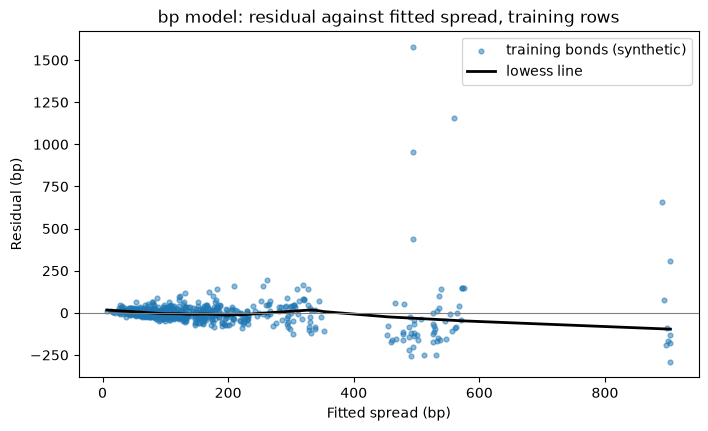

In [10]:
from statsmodels.nonparametric.smoothers_lowess import lowess

# lowess returns the fitted values sorted, with the smoothed residual beside each
smooth_bp = lowess(residuals_bp, fitted_bp, frac=0.3)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(fitted_bp, residuals_bp, s=12, alpha=0.5, label="training bonds (synthetic)")
ax.plot(smooth_bp[:, 0], smooth_bp[:, 1], color="black", linewidth=2, label="lowess line")
ax.axhline(0, color="grey", linewidth=0.8)
ax.set_title("bp model: residual against fitted spread, training rows")
ax.set_xlabel("Fitted spread (bp)")
ax.set_ylabel("Residual (bp)")
ax.legend()
plt.show()

Q. Put numbers on the picture: cut the training bonds into five equal groups by fitted spread, and average the residuals in each.

In [11]:
# five groups of equal size, from the lowest fitted spreads (1) to the highest (5)
quintile = pd.qcut(fitted_bp, 5, labels=False) + 1
by_fitted_bp = pd.DataFrame({
    "bonds": quintile.value_counts().sort_index(),
    "mean fitted (bp)": fitted_bp.groupby(quintile).mean().round(1),
    "mean residual (bp)": residuals_bp.groupby(quintile).mean().round(1),
}).rename_axis("fitted quintile")
by_fitted_bp

,bonds,mean fitted (bp),mean residual (bp)
fitted quintile,,,
1,123,51.6,6.2
2,123,90.7,-2.9
3,123,127.7,-2.0
4,123,190.6,-5.8
5,123,442.8,4.4


* The residuals average 6.2 bp in the lowest group and 4.4 bp in the highest, and below zero in the three groups between: the lowess line bends. The model adds a fixed number of bp per year of duration whatever the rating, while in the data a year of duration is worth more bp for a wide bond than for a tight one. Section 4.5 shows why.
* What it does to the fit: the fitted spreads lean the wrong way in parts of the range, by a few bp on average here. That is small next to the next check.

## 4.3 Constant Variance: the Fan

The same picture has a second shape: the residuals spread out as the fitted spread grows. That shape is called a **fan**, and its formal name is heteroskedasticity (unequal variance).

Q. How wide is the scatter in each of the five groups?

In [12]:
# the standard deviation of the residuals in each group, in bp
by_fitted_bp["residual sd (bp)"] = residuals_bp.groupby(quintile).std().round(1)
by_fitted_bp

,bonds,mean fitted (bp),mean residual (bp),residual sd (bp)
fitted quintile,,,,
1,123,51.6,6.2,18.0
2,123,90.7,-2.9,23.7
3,123,127.7,-2.0,34.3
4,123,190.6,-5.8,43.5
5,123,442.8,4.4,237.4


* 18.0 bp in the lowest group, 237.4 bp in the highest, rising in every step. A bond with a fitted spread near 51.6 bp is missed by a few tens of bp; one near 442.8 bp, by hundreds.

**The Breusch-Pagan test** turns the fan into one number. It squares the residuals and regresses them on the model's features. If the variance were constant, the features would account for almost none of the squared residuals. The statistic is the number of rows times that regression's R-squared (statsmodels' default, Koenker's form), and it is compared with a chi-squared distribution with one degree of freedom per feature.

**Reading a p-value.** A p-value answers one question: if the assumption held, how often would data show a pattern at least this strong, by chance alone? A small p-value means rarely. The course calls a p-value below 0.05 a rejection, as a convention. A p-value is not the probability that the assumption is true, and a large one does not prove it is.

Q. Run the Breusch-Pagan test on the bp model.

In [13]:
from statsmodels.stats.diagnostic import het_breuschpagan


def p_text(p):
    """A p-value for print: 3 significant figures, or "< 0.001"."""
    return "< 0.001" if p < 0.001 else f"{p:.3g}"


# returns the LM statistic and its p-value, then an F form of the same test; the LM pair is the one used here
lm, lm_pvalue, f_stat, f_pvalue = het_breuschpagan(residuals_bp, sm.add_constant(X_train))
print(f"Breusch-Pagan on the bp model: LM {lm:.2f} on {X_train.shape[1]} degrees of freedom, p-value {p_text(lm_pvalue)}")

Breusch-Pagan on the bp model: LM 51.63 on 27 degrees of freedom, p-value 0.00293


* LM 51.63, p-value 0.00293: if the variance of the errors were the same for every bond, a pattern this strong would turn up about 3 times in 1,000 samples. Constant variance is rejected.
* What it does: the coefficients are still the least squares fit, but the standard errors statsmodels prints assume constant variance. With a fan, those standard errors, and the t statistics, p-values, and intervals built from them, are not reliable: some are too small and some too large. The wide bonds also pull the fit toward themselves, because least squares weighs a miss of 200 bp four times as much as a miss of 100 bp.
* **Goldfeld-Quandt** (`het_goldfeldquandt` in statsmodels) is another published test for the same thing: it sorts the rows, fits the model on the first and last parts separately, and compares their residual variances. The course uses Breusch-Pagan, which Excel can reproduce. Standard errors that allow for a fan also exist (statsmodels' `cov_type="HC3"`, for example); today's route is to fix the shape instead.

## 4.4 Normality: the Q-Q Plot and Two Tests

The third assumption is that the errors are roughly normal. A **Q-Q plot** (quantile against quantile) sorts the residuals and plots each one against where it would sit if the residuals came from a normal distribution. Normal residuals lie on a straight line; a tail that bends away from it is a tail heavier than normal.

`scipy.stats.probplot` draws it: the theoretical normal quantiles go on the horizontal axis and the sorted residuals on the vertical one, with a straight line fitted through them.

Q. Draw the Q-Q plot of the bp model's residuals.

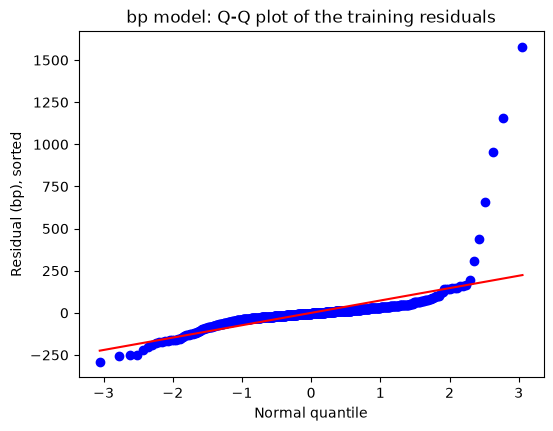

In [14]:
from scipy import stats

fig, ax = plt.subplots(figsize=(6, 4.5))
# probplot sorts the residuals, pairs them with normal quantiles, and draws the points and a fitted line
stats.probplot(residuals_bp, dist="norm", plot=ax)
ax.set_title("bp model: Q-Q plot of the training residuals")
ax.set_xlabel("Normal quantile")
ax.set_ylabel("Residual (bp), sorted")
plt.show()

* The middle lies near the line; the right end leaves it and climbs far above. A few bonds are missed by far more than a normal distribution would allow.

Two tests put a p-value on it:

| Test | What it measures | In Python |
| --- | --- | --- |
| Jarque-Bera | Skew (lopsidedness) and kurtosis (heavy tails) together, against a normal's 0 and 0 | `stats.jarque_bera` |
| Shapiro-Wilk | How closely the sorted residuals follow the normal quantiles | `stats.shapiro` |

Q. Run both, and print the skew and the excess kurtosis.

In [15]:
jb = stats.jarque_bera(residuals_bp)
sw = stats.shapiro(residuals_bp)
print(f"skew {stats.skew(residuals_bp):.2f}; excess kurtosis {stats.kurtosis(residuals_bp):.2f} (a normal has 0 and 0)")
print(f"Jarque-Bera p-value {p_text(jb.pvalue)}; Shapiro-Wilk p-value {p_text(sw.pvalue)}")

skew 8.20; excess kurtosis 100.23 (a normal has 0 and 0)
Jarque-Bera p-value < 0.001; Shapiro-Wilk p-value < 0.001


* A skew of 8.20 and an excess kurtosis of 100.23: the residuals have one long right tail. Both tests reject normality with p-values below 0.001: if the errors were normal, residuals this lopsided would essentially never turn up.
* What it does: the t statistics and intervals use the normal shape. With 615 rows the coefficients' own p-values lean on it less, because an average of many errors comes out close to normal anyway; an interval for a single bond's spread leans on it fully, and with a tail like this one it is wrong.

Q. Put the three tests in one function: add `residual_tests` to `mlkit.py`, docstring first.

In [16]:
%%writefile -a mlkit.py


from scipy import stats  # Jarque-Bera and Shapiro-Wilk
from statsmodels.stats.diagnostic import het_breuschpagan  # Breusch-Pagan
from statsmodels.tools import add_constant  # the intercept column


def residual_tests(residuals: pd.Series, exog: pd.DataFrame) -> dict[str, float]:
    """p-values of three checks on a regression's residuals: constant variance and normality (two tests).

    Inputs: residuals, actual minus fitted on the training rows, in the target's unit; exog, the features the
    model was fitted on, without a constant (one is added inside), with the same rows.
    Output: {"breusch_pagan", "jarque_bera", "shapiro_wilk"}, each a p-value between 0 and 1. A small p-value
    (below 0.05, the course's convention) means the data would be surprising if the assumption held:
    - breusch_pagan: statsmodels het_breuschpagan with its default (Koenker's form, n x R-squared of the squared
      residuals regressed on a constant and exog); the assumption is constant variance;
    - jarque_bera: scipy.stats.jarque_bera (skew and kurtosis); the assumption is normal residuals;
    - shapiro_wilk: scipy.stats.shapiro; the assumption is normal residuals.
    Excel has no function for these; Breusch-Pagan can be built from LINEST and CHISQ.DIST.RT.
    Raises ValueError if the inputs are empty or have different numbers of rows.
    """
    # check the two inputs line up
    if len(residuals) == 0 or len(exog) == 0:
        raise ValueError("residuals and exog must not be empty")
    if len(residuals) != len(exog):
        raise ValueError(f"residuals has {len(residuals)} rows and exog has {len(exog)}")
    values = np.asarray(residuals, dtype=float)
    # Breusch-Pagan: returns the LM statistic, its p-value, then an F form; the LM p-value is kept
    _, bp_pvalue, _, _ = het_breuschpagan(values, add_constant(np.asarray(exog, dtype=float), has_constant="add"))
    # the two normality tests
    jb_pvalue = stats.jarque_bera(values).pvalue
    sw_pvalue = stats.shapiro(values).pvalue
    return {"breusch_pagan": float(bp_pvalue), "jarque_bera": float(jb_pvalue), "shapiro_wilk": float(sw_pvalue)}

Appending to mlkit.py


* The imports a fragment needs go at its top, as on every day. `residual_tests` takes the residuals and the features the model was fitted on, adds the constant itself, and returns three p-values in a dictionary. It checks that the two inputs line up before it computes anything.

Q. Add three tests: agreement with statsmodels, scipy, and Excel's Breusch-Pagan by hand; a normal sample that is not rejected; a hand-built fan that is.

In [17]:
%%writefile -a test_mlkit.py


from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan


def test_residual_tests_match_statsmodels_and_scipy():
    bench = read_bench()
    X = pd.concat([mlkit.rating_dummies(bench["rating"], rating_levels(), reference="A"),
                   bench[["duration"]], sector_dummies(bench["sector"])], axis=1)
    fit = sm.OLS(bench["log_oas"], sm.add_constant(X)).fit()
    result = mlkit.residual_tests(fit.resid, X)
    assert result["breusch_pagan"] == pytest.approx(het_breuschpagan(fit.resid, sm.add_constant(X))[1], abs=1e-12)
    assert result["jarque_bera"] == pytest.approx(stats.jarque_bera(fit.resid).pvalue, abs=1e-12)
    assert result["shapiro_wilk"] == pytest.approx(stats.shapiro(fit.resid).pvalue, abs=1e-12)
    # Excel: LM = n x INDEX(LINEST(squared residuals, X, TRUE, TRUE), 3, 1), then CHISQ.DIST.RT(LM, k)
    model = "d04_breusch_pagan_log_oas_model"
    assert het_breuschpagan(fit.resid, sm.add_constant(X))[0] == pytest.approx(excel(f"{model}:lm"), rel=1e-9)
    assert result["breusch_pagan"] == pytest.approx(excel(f"{model}:lm_pvalue"), abs=1e-9)


def test_residual_tests_normal_sample():
    rng = np.random.default_rng(SEED)
    exog = pd.DataFrame({"x": rng.uniform(0, 10, 500)})
    residuals = pd.Series(rng.normal(0, 1, 500))
    # residuals drawn normal with constant variance: no check rejects at 0.05
    result = mlkit.residual_tests(residuals, exog)
    assert min(result.values()) > 0.05


def test_residual_tests_fan_rejected():
    rng = np.random.default_rng(SEED)
    x = np.arange(1.0, 201.0)
    # the spread of the residuals grows with x: a fan
    residuals = pd.Series(x * rng.normal(0, 1, 200))
    result = mlkit.residual_tests(residuals, pd.DataFrame({"x": x}))
    assert result["breusch_pagan"] < 0.001
    with pytest.raises(ValueError):
        mlkit.residual_tests(residuals, pd.DataFrame({"x": x[:10]}))

Appending to test_mlkit.py


* The second and third tests make their own data with `np.random.default_rng(SEED)`: residuals drawn from a normal distribution with constant variance, which no check should reject; and residuals whose spread grows with x, which Breusch-Pagan must reject.

Q. Reload the module and run all the tests.

In [18]:
# the file changed, so reload before using the new function
importlib.reload(mlkit)
print(f"residual_tests in mlkit: {hasattr(mlkit, 'residual_tests')}")

residual_tests in mlkit: True


In [19]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_mlkit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

.................                                                        [100%]
17 passed in 1.92s



* `17 passed`: day 3's 14 and today's three.

Q. Run the three checks on the bp model in one line.

In [20]:
tests_bp = mlkit.residual_tests(residuals_bp, X_train)
print("bp model, training rows: " + ", ".join(f"{name} {p_text(p)}" for name, p in tests_bp.items()))

bp model, training rows: breusch_pagan 0.00293, jarque_bera < 0.001, shapiro_wilk < 0.001


* All three reject. The coefficients of the bp model are a least squares fit, and its printed standard errors and p-values rest on two assumptions the residuals reject.

## 4.5 Why the bp Model Fans: the Generator Multiplies

The recipe that made these spreads, from day 1:

oas = round( base(score) x (0.70 + 0.30 x min(T, 10) / 10) x issuer effect x noise )

Every part **multiplies**. The noise is a lognormal draw with sigma 0.18, so it moves a spread by a similar **percentage** whatever the rating, and a similar percentage of a wide spread is many more bp.

Q. How large, in bp, is the generator's noise for a typical 10-year bond of each rating?

In [21]:
# the generator's base OAS for a 10-year bond, in bp, copied from tools/make_holdings.py (read, never run)
generator_base_bp = pd.Series({1: 30, 2: 40, 3: 48, 4: 56, 5: 68, 6: 80, 7: 95, 8: 115, 9: 135, 10: 165, 11: 215, 12: 260, 13: 310, 14: 370, 15: 440, 16: 530, 17: 720, 18: 900})

# the standard deviation of a lognormal draw with sigma 0.18 is this share of the value it multiplies
sigma = 0.18
noise_share = np.sqrt(np.exp(sigma ** 2) * (np.exp(sigma ** 2) - 1))

noise_table = pd.DataFrame({
    "rating": ratings.set_index("score")["rating"],
    "base (bp)": generator_base_bp,
    "noise sd (bp)": (generator_base_bp * noise_share).round(1),
}).rename_axis("score").loc[[1, 6, 9, 12, 15, 18]]
print(f"the noise has a standard deviation of {noise_share:.1%} of the spread it multiplies")
noise_table

the noise has a standard deviation of 18.4% of the spread it multiplies


,rating,base (bp),noise sd (bp)
score,,,
1,AAA,30,5.5
6,A,80,14.8
9,BBB,135,24.9
12,BB,260,48.0
15,B,440,81.1
18,CCC,900,166.0


* The same 18.4% is 5.5 bp for an AAA bond and 166.0 bp for a CCC bond. That is the fan: the spread of the errors grows with the level of the spread, because the recipe multiplies. The duration curve in 4.2 has the same cause: the maturity factor multiplies the base too, so a year of maturity adds more bp to a wide bond.

**Logs turn multiplying into adding.** log(a x b x c) = log(a) + log(b) + log(c). In logs the recipe becomes

log(oas) = log(base) + log(maturity factor) + log(issuer effect) + log(noise)

and log(noise) is a normal draw with standard deviation 0.18 for **every** bond, tight or wide. A linear model of `log_oas` has the shape of the recipe, and its errors should have a constant spread.

## 4.6 The Log Model: Refit, Recheck, and Read a Coefficient

Q. Fit the same features to the log of OAS on the same training rows.

In [22]:
# the same 27 features and training rows; the target is now the natural log of OAS in bp
y_train_log = np.log(y_train)
fit_log = sm.OLS(y_train_log, sm.add_constant(X_train)).fit()
residuals_log = fit_log.resid
fitted_log = fit_log.fittedvalues
print(f"log model: {int(fit_log.nobs)} training rows, R-squared {fit_log.rsquared:.4f} (in logs, not comparable with the bp model's {fit_bp.rsquared:.4f})")

log model: 615 training rows, R-squared 0.8920 (in logs, not comparable with the bp model's 0.6768)


* The two R-squared values measure variation in different units, log bp and bp, so they cannot be compared. Section 4.7 compares the two models in the same unit, bp, on the test rows.

Q. Draw the two pictures again for the log model.

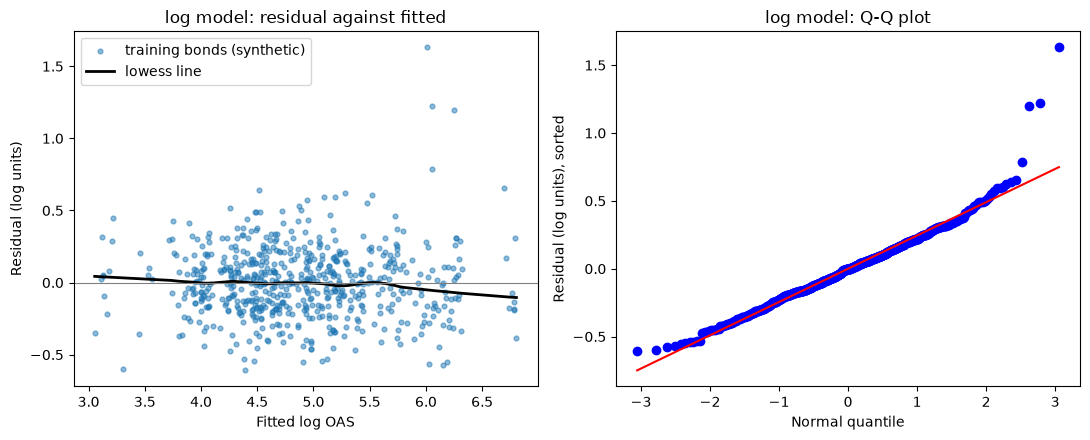

In [23]:
smooth_log = lowess(residuals_log, fitted_log, frac=0.3)

fig, (left, right) = plt.subplots(1, 2, figsize=(11, 4.5))
left.scatter(fitted_log, residuals_log, s=12, alpha=0.5, label="training bonds (synthetic)")
left.plot(smooth_log[:, 0], smooth_log[:, 1], color="black", linewidth=2, label="lowess line")
left.axhline(0, color="grey", linewidth=0.8)
left.set_title("log model: residual against fitted")
left.set_xlabel("Fitted log OAS")
left.set_ylabel("Residual (log units)")
left.legend()
stats.probplot(residuals_log, dist="norm", plot=right)
right.set_title("log model: Q-Q plot")
right.set_xlabel("Normal quantile")
right.set_ylabel("Residual (log units), sorted")
plt.tight_layout()
plt.show()

In [24]:
quintile_log = pd.qcut(fitted_log, 5, labels=False) + 1
by_fitted_log = pd.DataFrame({
    "mean fitted (log)": fitted_log.groupby(quintile_log).mean().round(2),
    "mean residual": residuals_log.groupby(quintile_log).mean().round(3),
    "residual sd": residuals_log.groupby(quintile_log).std().round(3),
}).rename_axis("fitted quintile")
tests_log = mlkit.residual_tests(residuals_log, X_train)
print("log model, training rows: " + ", ".join(f"{name} {p_text(p)}" for name, p in tests_log.items()))
by_fitted_log

log model, training rows: breusch_pagan 0.00786, jarque_bera < 0.001, shapiro_wilk < 0.001


,mean fitted (log),mean residual,residual sd
fitted quintile,,,
1,3.95,-0.001,0.207
2,4.47,0.008,0.240
3,4.80,-0.006,0.237
4,5.21,-0.015,0.223
5,5.96,0.014,0.326


* The lowess line is flat: the mean residual in every group is within 0.015 of zero, so the curve of 4.2 is gone. The residual sd is 0.207 to 0.240 in the first four groups, with no fan, close to 0.234, the spread of the generator's noise and issuer effect together (the square root of 0.18 squared plus 0.15 squared). The highest group is wider, at 0.326.
* The tests still reject: Breusch-Pagan 0.00786, Jarque-Bera < 0.001, Shapiro-Wilk < 0.001. The Q-Q plot shows why: a handful of points far above the line at the right end. Section 4.8 finds them.

**Reading a coefficient in a log model.** A coefficient b on `log_oas` is a difference in log spread. exp(b) is the ratio of the fitted spreads, so a one-unit difference in the feature, other features fixed, goes with a difference of 100 x (exp(b) - 1) percent in the fitted spread. For a small b, that is close to 100 x b percent.

Q. Read the duration coefficient, and four rating coefficients, as percent changes.

In [25]:
# duration: one more year of duration, same rating and sector
b_duration = fit_log.params["duration"]
print(f"duration: coefficient {b_duration:.4f}, so {100 * (np.exp(b_duration) - 1):.2f} percent wider per year of duration, other features fixed")

# rating dummies: the difference from an A-rated bond (the reference), same duration and sector
rating_reading = pd.DataFrame({"coefficient": fit_log.params[[f"rating_{r}" for r in ['AAA', 'BBB', 'BB', 'B']]]})
rating_reading.index = ['AAA', 'BBB', 'BB', 'B']
rating_reading["percent vs A"] = (100 * (np.exp(rating_reading["coefficient"]) - 1)).round(1)
# the generator's own base spreads, as a percent difference from A's
base_by_rating = generator_base_bp.rename(ratings.set_index("score")["rating"])
rating_reading["generator base vs A (percent)"] = (100 * (base_by_rating[rating_reading.index] / base_by_rating["A"] - 1)).round(1)
rating_reading["coefficient"] = rating_reading["coefficient"].round(4)
rating_reading

duration: coefficient 0.0200, so 2.02 percent wider per year of duration, other features fixed


,coefficient,percent vs A,generator base vs A (percent)
AAA,-1.1234,-67.5,-62.5
BBB,0.4712,60.2,68.8
BB,1.1476,215.1,225.0
B,1.7408,470.2,450.0


* Duration: 0.0200, or 2.02 percent per year of duration, the same for a tight bond and a wide one. In the bp model, one coefficient had to serve both.
* Ratings: a B-rated bond's fitted spread is 470.2 percent above an A-rated bond's of the same duration and sector, against 450.0 percent between the generator's two base spreads; an AAA bond's is 67.5 percent below, against 62.5 percent. The log model recovers the generator's rating table closely, though not exactly: each rating holds a few issuers, and their issuer effects do not average out. Day 5 sets the whole table beside the generator's.
* Read every coefficient as an association in this data: holding the other features fixed, a one-unit difference in the feature goes with this percent difference in the fitted spread. It is not a cause.

## 4.7 Back to bp: exp, the Test MAE, and What exp Returns

A desk reads an error in bp. A log model's fitted values are logs, so they go back to bp with `exp` before they are compared with OAS. Now the test rows are used, once, for the reported numbers of both models.

Q. Compare the two models on the test rows, both in bp.

In [26]:
# the models' output for the test rows; has_constant="add" adds the intercept even if a column happens to be constant there
X_test_c = sm.add_constant(X_test, has_constant="add")
fitted_test_bp = fit_bp.predict(X_test_c)
fitted_test_log = fit_log.predict(X_test_c)
# back to bp: exp of the fitted log spread
fitted_test_from_log = np.exp(fitted_test_log)

test_table = pd.DataFrame({
    "bp model": mlkit.regression_metrics(y_test, fitted_test_bp),
    "log model, exp to bp": mlkit.regression_metrics(y_test, fitted_test_from_log),
}).T.rename(columns={"r2": "R-squared", "mae": "MAE (bp)", "rmse": "RMSE (bp)"})
test_table.round({"R-squared": 4, "MAE (bp)": 1, "RMSE (bp)": 1})

,R-squared,MAE (bp),RMSE (bp)
bp model,0.8149,36.3,69.7
"log model, exp to bp",0.8174,33.3,69.2


* On 206 bonds the model never saw, the log model misses by 33.3 bp on average against the bp model's 36.3 bp: the course's main number moves 3.1 bp in its favour. The R-squared values are close (0.8174 against 0.8149), and so are the RMSEs (69.2 against 69.7 bp): RMSE is dominated by the few widest bonds, which both models miss by a lot.
* The log model's advantage today is less about its test error than about its residuals: they meet the assumptions behind its standard errors far better, apart from a few bonds.

**What `exp` of a fitted log is.** The log model fits the average of log OAS. Taking `exp` of an average of logs gives a middle value, close to the median spread for bonds like this one, not the mean: half the bonds sit above it and half below, and because spreads have a long right tail the mean is higher than the median.

Q. How many test bonds sit above their fitted spread, and how do the averages compare?

In [27]:
above = (y_test > fitted_test_from_log).sum()
print(f"test bonds wider than exp of their fitted log spread: {above} of {len(y_test)}")
print(f"mean actual OAS {y_test.mean():.1f} bp; mean of exp(fitted) {fitted_test_from_log.mean():.1f} bp")

test bonds wider than exp of their fitted log spread: 108 of 206
mean actual OAS 174.3 bp; mean of exp(fitted) 166.0 bp


* 108 of 206, close to half, and the mean of `exp(fitted)` is 8.3 bp below the mean actual spread. That is what a median-type value does. Published corrections exist that scale `exp(fitted)` up to estimate a mean; the course applies none, and says so whenever it reports a log model in bp.

## 4.8 The Six Distressed Bonds

The generator picked six bonds rated B or lower and multiplied their spreads by 2.5 to 4, as distressed bonds. The file does not mark them. A multiplier of 2.5 to 4 adds 0.92 to 1.39 to a log spread, while the issuer effect is shared by an issuer's bonds, so a distressed bond should sit far above the other bonds of its own issuer.

Q. Among bonds rated B or lower, which six sit furthest above their issuer's median log spread?

This is **description** of the whole file, to find the bonds; nothing here builds a feature.

In [28]:
# each bond's log spread minus the median log spread of its issuer's bonds
gap_to_issuer = bench["log_oas"] - bench.groupby("ticker")["log_oas"].transform("median")
# the generator's rule: rating score 15 (B) or worse
weak = bench["score"] >= 15
ranked = gap_to_issuer[weak].sort_values(ascending=False)
six = ranked.index[:6]

six_table = bench.loc[six, ["cusip", "issuer", "rating", "oas"]].copy()
six_table["gap to issuer (log)"] = ranked.iloc[:6].round(2)
six_table["side"] = np.where(six.isin(X_train.index), "training", "test")
print(f"the next bond rated B or lower: a gap of {ranked.iloc[6]:.2f}")
six_table

the next bond rated B or lower: a gap of 0.43


,cusip,issuer,rating,oas,gap to issuer (log),side
386,99072UAF5,Zephane Utilities,B,2074,1.74,training
47,99009JAA9,Calderby Retail,B,1446,1.19,training
789,99145PAB8,Praximer Energy,B-,1718,1.15,training
533,99098UAF5,Elvundra Foods,B,933,0.92,training
365,99069RAC4,Feskovar Devices,CCC+,1551,0.70,training
196,99038MAC3,Praxiskan Finance,CCC+,1605,0.56,test


* Six bonds stand out, with gaps from 0.56 to 1.74; the next bond rated B or lower is at 0.43. Taking the generator's maturity factor out first gives the same six. They are the most likely six, read from the data: the file itself names none.
* 5 of them are training rows and 1 is a test row. The issuers are invented, and so are the spreads.

Q. Run the checks on the log model with and without the 5 distressed training bonds, and on the bp model the same way.

In [29]:
keep = ~X_train.index.isin(six)
print(f"training rows without the distressed bonds: {keep.sum()}")

checks = {}
for name, target in [("log model", np.log(y_train)), ("bp model", y_train)]:
    for label, rows in [("all training rows", X_train.index), ("without the six", X_train.index[keep])]:
        fit = sm.OLS(target.loc[rows], sm.add_constant(X_train.loc[rows])).fit()
        checks[(name, label)] = {test: p_text(p) for test, p in mlkit.residual_tests(fit.resid, X_train.loc[rows]).items()}
pd.DataFrame(checks).T

training rows without the distressed bonds: 610


breusch_pagan jarque_bera shapiro_wilk
log model all training rows       0.00786     < 0.001      < 0.001
          without the six           0.632       0.709        0.738
bp model  all training rows       0.00293     < 0.001      < 0.001
          without the six         < 0.001     < 0.001      < 0.001

* Without them, the log model passes all three checks: Breusch-Pagan 0.632, Jarque-Bera 0.709, Shapiro-Wilk 0.738. Everything the tests rejected in logs came from 5 bonds out of 615. Their residuals in the log model run from 0.66 to 1.63, against a residual sd of about 0.23 for the other bonds.
* The bp model still fails all three without them (Breusch-Pagan < 0.001, Jarque-Bera < 0.001, Shapiro-Wilk < 0.001). Its problem is its shape, not a few bonds.

**The six are kept.** They are part of the data, not errors in it: the recipe made them on purpose, and spreads of distressed bonds are a real feature of credit. Dropping rows because they fail a test chooses the data to suit the model, and a model fitted without them would report errors that are too small for exactly the bonds where errors are largest. What changes is the reading: the log model's p-values describe the other 610 training bonds well and these few badly, and the notebook says so.

## Excel Side by Side

Excel has no worksheet function for any of today's residual tests: not Breusch-Pagan, not Jarque-Bera, not Shapiro-Wilk. It can build Breusch-Pagan by hand from `LINEST`, and it can compute the points of a Q-Q plot. The training rows from the course split go on a sheet named `train`: OAS in bp in column A, `log_oas` in B, the 27 features in C to AC, headers in row 1, rows 2 to 616. The test rows go on a sheet named `test` the same way. Every formula below was typed into Excel by script on those rows (Excel 16.0 build 20430, 2026-10-04).

| Job | Python | Excel | Excel returned |
| --- | --- | --- | --- |
| Log of OAS | `np.log(y_train)` | `=LN(A2)` in B2, filled down | equal to Python |
| Fitted values, bp model | `fit_bp.fittedvalues` | `=TREND($A$2:$A$616,$C$2:$AC$616)` in AD2 (spills down) | equal within 1e-9 |
| Residual and its square | `fit_bp.resid ** 2` | `=A2-AD2` in AE2, `=AE2^2` in AF2, filled down | |
| Breusch-Pagan LM, bp model | `het_breuschpagan(...)[0]` | `=ROWS(AF2:AF616)*INDEX(LINEST(AF2:AF616,$C$2:$AC$616,TRUE,TRUE),3,1)` in AM1 | 51.63 |
| Its p-value | `residual_tests(...)["breusch_pagan"]` | `=CHISQ.DIST.RT(AM1,COLUMNS($C$2:$AC$616))` in AM2 | 0.00293 |
| The same, log model | | the same formulas on columns AH to AJ, the LM in AM3 and its p-value in AM4 | LM 47.91, p-value 0.00786 |
| Q-Q point of each log residual | `stats.norm.ppf((rank - 0.5) / n)` | `=NORM.S.INV((RANK.EQ(AI2,$AI$2:$AI$616,1)-0.5)/COUNT($AI$2:$AI$616))` in AK2, filled down | equal within 1e-9 |
| Fitted log spread, test rows | `fit_log.predict(...)` | `=TREND(train!$B$2:$B$616,train!$C$2:$AC$616,C2:AC207)` in AD2 of `test` | equal within 1e-9 |
| Back to bp | `np.exp(...)` | `=EXP(AD2)` in AE2, filled down | equal within 1e-9 |
| Test MAE in bp, log model | `regression_metrics(y_test, np.exp(...))["mae"]` | `=AVERAGE(ABS(A2:A207-EXP(AD2:AD207)))` | 33.3 bp |

**Breusch-Pagan in three columns.** `TREND(known_y, known_x)` with no new x returns the fitted value of every training row, so it spills down column AD: that is the model's fit, done by Excel's own least squares. Column AE subtracts it from OAS, AF squares the result. Then one cell does the test: `LINEST` regresses the squared residuals on the same 27 features, `INDEX(..., 3, 1)` picks the R-squared from the third row of LINEST's output, and multiplying by `ROWS`, the number of rows, gives the LM statistic. `CHISQ.DIST.RT(LM, COLUMNS(X))` is the right tail of the chi-squared distribution with one degree of freedom per feature, which is the p-value. It equals statsmodels' default, the n x R-squared form; statsmodels' other form, with `robust=False`, gives a different number.

**Q-Q points, and a different set of positions.** `RANK.EQ(r, range, 1)` is each residual's rank from the smallest, `(rank - 0.5) / COUNT(range)` turns the rank into a share between 0 and 1, and `NORM.S.INV` returns the normal quantile at that share. Plotted against the residuals, these points make a Q-Q plot. They are **not** the points `stats.probplot` draws, which use a slightly different share for each rank (Filliben's positions): at the smallest residual Excel's position is -3.151 and probplot's -3.055. The picture looks the same; the numbers at the ends differ.

**`EXP` and the units.** In the test sheet, `AVERAGE(ABS(A2:A207-EXP(AD2:AD207)))` takes `EXP` of each fitted log spread inside the formula, then the mean absolute difference from OAS, in bp. Typed in this Excel, which has dynamic arrays, it works with Enter. Leave out `EXP`, `=AVERAGE(ABS(A2:A207-AD2:AD207))`, and Excel returns 169.4: bp minus log bp, a number with no unit. The exercises come back to it.

In [30]:
# Excel's numbers, from the day's Excel check, beside Python's for the same rows
lm_log = het_breuschpagan(residuals_log, sm.add_constant(X_train))[0]
excel = {"LM, bp model": 51.63150975232133, "p-value, bp model": 0.0029331099371744497,
         "LM, log model": 47.90928524721261, "p-value, log model": 0.00785923877384387,
         "test MAE in bp, log model": 33.2540806382107}
python = {"LM, bp model": lm, "p-value, bp model": tests_bp["breusch_pagan"],
          "LM, log model": lm_log, "p-value, log model": tests_log["breusch_pagan"],
          "test MAE in bp, log model": mlkit.regression_metrics(y_test, fitted_test_from_log)["mae"]}

side_by_side = pd.DataFrame({"Excel": excel, "Python": python})
side_by_side["within 1e-9"] = (side_by_side["Excel"] - side_by_side["Python"]).abs() < 1e-9
side_by_side.round({"Excel": 4, "Python": 4})

,Excel,Python,within 1e-9
"LM, bp model",51.6315,51.6315,True
"p-value, bp model",0.0029,0.0029,True
"LM, log model",47.9093,47.9093,True
"p-value, log model",0.0079,0.0079,True
"test MAE in bp, log model",33.2541,33.2541,True


Q. Where do Excel's Q-Q positions and probplot's differ most?

In [31]:
# Excel's positions: NORM.S.INV((rank - 0.5) / n); probplot's: Filliben's, returned as its first output
n = len(residuals_log)
ranks = stats.rankdata(residuals_log, method="min")   # RANK.EQ gives ties the lowest rank, as method="min" does
excel_positions = np.sort(stats.norm.ppf((ranks - 0.5) / n))
(probplot_positions, sorted_residuals), _ = stats.probplot(residuals_log, dist="norm")

positions = pd.DataFrame({"Excel (i - 0.5) / n": excel_positions, "probplot": probplot_positions})
positions["difference"] = positions["Excel (i - 0.5) / n"] - positions["probplot"]
print(f"Excel at the smallest residual: {excel_positions[0]:.3f} (Excel returned -3.151); probplot: {probplot_positions[0]:.3f}")
positions.iloc[[0, 1, 2, n // 2, n - 1]].round(3)

Excel at the smallest residual: -3.151 (Excel returned -3.151); probplot: -3.055


,Excel (i - 0.5) / n,probplot,difference
0,-3.151,-3.055,-0.097
1,-2.815,-2.778,-0.037
2,-2.647,-2.623,-0.024
307,0.000,0.000,0.000
614,3.151,3.055,0.097


* The two sets of positions agree near the middle and differ most at the ends, by 0.097 at the smallest residual. Both are published conventions; neither is a mistake. If you rebuild a Q-Q plot in Excel, expect the end points to sit slightly outside probplot's.

## Save the Day with Git

Today's Git step is `git stash`: put an experiment aside without committing it, compare it with what is committed, and throw it away. First the usual start, the module, and the experiment log.

Q. Make the work folder a repository.

In [32]:
# stop here, with the steps to install it, if Git is not on this machine
if shutil.which("git") is None:
    raise RuntimeError("Git is not installed. Install Git for Windows from https://git-scm.com/downloads "
                       "(or run  winget install --id Git.Git  where your firm allows it), restart VS Code, "
                       "and run this cell again. Colab has Git already.")

# -C "{work}" points every Git command at the work folder, whatever folder the notebook is in
!git -C "{work}" --version
# make the work folder a repository
!git -C "{work}" init -q -b main
# settings for this repository only: a course name, a reserved example email, line endings left as they are,
# and no commit signing, so a signing setup on your machine does not ask for a key here
!git -C "{work}" config user.name "Course Student"
!git -C "{work}" config user.email "student@example.com"
!git -C "{work}" config core.autocrlf false
!git -C "{work}" config commit.gpgsign false

git version 2.50.1.windows.1


Q. Is Git working in the work folder, and only there?

In [33]:
# the guard: Git must report the work folder as the top of this repository, or the notebook stops
top = subprocess.run(["git", "-C", str(work), "rev-parse", "--show-toplevel"],
                     capture_output=True, text=True, check=True).stdout.strip()
assert os.path.samefile(top, work), "Git is not working in the work folder. Stop, and run the setup cell again."
print(f"Git is working in {work.name} and nowhere else")

Git is working in pfi_course4_04_heomg27b and nowhere else


Q. Add the `.gitignore` of day 1, and commit the module and its tests.

In [34]:
%%writefile .gitignore
__pycache__/
.pytest_cache/
*.xlsx

Writing .gitignore


In [35]:
!git -C "{work}" add .gitignore mlkit.py test_mlkit.py
!git -C "{work}" commit -q -m "Day 4: residual_tests (Breusch-Pagan, Jarque-Bera, Shapiro-Wilk), with three tests"
!git -C "{work}" log --oneline

24b6758 Day 4: residual_tests (Breusch-Pagan, Jarque-Bera, Shapiro-Wilk), with three tests


Q. Write today's two models to `results.csv`, the experiment log, with 4 decimals, and commit it.

In [36]:
# one row per model; MAE and RMSE in bp on the test rows (the log model after exp)
results = pd.DataFrame([
    {"model": "oas_on_rating_duration_sector", "features": "rating dummies (ref A), duration, sector dummies",
     "train_rows": len(X_train), "test_rows": len(X_test), **{f"test_{k}": v for k, v in mlkit.regression_metrics(y_test, fitted_test_bp).items()}},
    {"model": "log_oas_on_rating_duration_sector", "features": "rating dummies (ref A), duration, sector dummies",
     "train_rows": len(X_train), "test_rows": len(X_test), **{f"test_{k}": v for k, v in mlkit.regression_metrics(y_test, fitted_test_from_log).items()}},
]).rename(columns={"test_mae": "test_mae_bp", "test_rmse": "test_rmse_bp"})
# 4 decimals; "\n" line endings, so the file and its diffs are the same on every machine
results.to_csv("results.csv", index=False, float_format="%.4f", lineterminator="\n")
print((work / "results.csv").read_text(encoding="utf-8"))

model,features,train_rows,test_rows,test_r2,test_mae_bp,test_rmse_bp
oas_on_rating_duration_sector,"rating dummies (ref A), duration, sector dummies",615,206,0.8149,36.3359,69.7107
log_oas_on_rating_duration_sector,"rating dummies (ref A), duration, sector dummies",615,206,0.8174,33.2541,69.2360



In [37]:
!git -C "{work}" add results.csv
!git -C "{work}" commit -q -m "Experiment log: the bp model and the log model, test metrics in bp"
!git -C "{work}" log --oneline

694200b Experiment log: the bp model and the log model, test metrics in bp
24b6758 Day 4: residual_tests (Breusch-Pagan, Jarque-Bera, Shapiro-Wilk), with three tests


* The columns are day 1's: `model, features, train_rows, test_rows, test_r2, test_mae_bp, test_rmse_bp`.

Q. Try an experiment: a model of the square root of OAS, which also shrinks wide spreads, though less than the log does. Add its row to `results.csv` without committing.

In [38]:
# the same features and training rows; target the square root of OAS in bp; back to bp by squaring
fit_sqrt = sm.OLS(np.sqrt(y_train), sm.add_constant(X_train)).fit()
fitted_test_from_sqrt = fit_sqrt.predict(X_test_c) ** 2
tests_sqrt = mlkit.residual_tests(fit_sqrt.resid, X_train)
print("square-root model, training rows: " + ", ".join(f"{name} {p_text(p)}" for name, p in tests_sqrt.items()))

sqrt_row = {"model": "sqrt_oas_on_rating_duration_sector", "features": "rating dummies (ref A), duration, sector dummies",
            "train_rows": len(X_train), "test_rows": len(X_test),
            **{f"test_{k}": v for k, v in mlkit.regression_metrics(y_test, fitted_test_from_sqrt).items()}}
experiment = pd.concat([results, pd.DataFrame([sqrt_row]).rename(columns={"test_mae": "test_mae_bp", "test_rmse": "test_rmse_bp"})])
experiment.to_csv("results.csv", index=False, float_format="%.4f", lineterminator="\n")

square-root model, training rows: breusch_pagan < 0.001, jarque_bera < 0.001, shapiro_wilk < 0.001


In [39]:
# M marks a tracked file changed since the last commit; diff shows the line the experiment added
!git -C "{work}" status --short results.csv
!git -C "{work}" diff results.csv

 M results.csv


diff --git a/results.csv b/results.csv
index 53f0414..8544e1e 100644
--- a/results.csv
+++ b/results.csv
@@ -1,3 +1,4 @@
 model,features,train_rows,test_rows,test_r2,test_mae_bp,test_rmse_bp
 oas_on_rating_duration_sector,"rating dummies (ref A), duration, sector dummies",615,206,0.8149,36.3359,69.7107
 log_oas_on_rating_duration_sector,"rating dummies (ref A), duration, sector dummies",615,206,0.8174,33.2541,69.2360
+sqrt_oas_on_rating_duration_sector,"rating dummies (ref A), duration, sector dummies",615,206,0.8238,33.9574,68.0136


* The square-root model's test MAE is 34.0 bp, against 33.3 bp for the log model, and its R-squared is 0.8238 (a little higher than the log model's). Its residuals fail all three checks, and they still fail without the six distressed bonds: the square root is not the shape of a recipe that multiplies.

Q. Put the experiment aside with `git stash`, and look at the file.

In [40]:
# stash saves the uncommitted change and puts the committed file back
!git -C "{work}" stash push -q -m "square-root target, an experiment"
!git -C "{work}" status --short results.csv
!git -C "{work}" stash list

stash@{0}: On main: square-root target, an experiment


In [41]:
# the file is back to the two committed rows
print((work / "results.csv").read_text(encoding="utf-8"))

model,features,train_rows,test_rows,test_r2,test_mae_bp,test_rmse_bp
oas_on_rating_duration_sector,"rating dummies (ref A), duration, sector dummies",615,206,0.8149,36.3359,69.7107
log_oas_on_rating_duration_sector,"rating dummies (ref A), duration, sector dummies",615,206,0.8174,33.2541,69.2360



* `git status` prints nothing for `results.csv`: the file matches the last commit. The experiment is not lost: `stash list` shows it as `stash@{0}`, with the message.

Q. Compare the stashed experiment with the committed file, then decide.

In [42]:
# the latest stash as a diff against the commit it was made on
!git -C "{work}" stash show -p

diff --git a/results.csv b/results.csv
index 53f0414..8544e1e 100644
--- a/results.csv
+++ b/results.csv
@@ -1,3 +1,4 @@
 model,features,train_rows,test_rows,test_r2,test_mae_bp,test_rmse_bp
 oas_on_rating_duration_sector,"rating dummies (ref A), duration, sector dummies",615,206,0.8149,36.3359,69.7107
 log_oas_on_rating_duration_sector,"rating dummies (ref A), duration, sector dummies",615,206,0.8174,33.2541,69.2360
+sqrt_oas_on_rating_duration_sector,"rating dummies (ref A), duration, sector dummies",615,206,0.8238,33.9574,68.0136


* The same added line as before. The log model stays: it has the shape of the recipe, its residuals pass every check without the six distressed bonds, and its test MAE is lower. The experiment is dropped.

In [43]:
# drop deletes the stash; stash list is now empty, and the history holds only the two commits
!git -C "{work}" stash drop -q
!git -C "{work}" stash list
!git -C "{work}" log --oneline

694200b Experiment log: the bp model and the log model, test metrics in bp
24b6758 Day 4: residual_tests (Breusch-Pagan, Jarque-Bera, Shapiro-Wilk), with three tests


* `git stash pop` would have put the change back into the file instead, and `git stash apply` would do the same and keep the stash too. A stash is for a short experiment you might want back in the next hour; anything you want to keep belongs in a commit.

## Bring It Home

Add today's function and tests to your own `my_bondmath` folder. No new data file is needed: today's tests read the three files you copied on day 1. Open a PowerShell terminal in VS Code.

```powershell
Set-Location "$HOME\projects\python-fixed-income"
.\.venv\Scripts\Activate.ps1
Set-Location "$HOME\projects\my_bondmath"
code mlkit.py
code test_mlkit.py
```

Paste the code of today's `%%writefile -a mlkit.py` cell (section 4.4), without its first line, at the end of `mlkit.py`, and the `%%writefile -a test_mlkit.py` cell at the end of `test_mlkit.py`. Save both, then run the tests and commit the code.

```powershell
python -m pytest -q test_mlkit.py
git add mlkit.py test_mlkit.py
git commit -m "Day 4: residual_tests (Breusch-Pagan, Jarque-Bera, Shapiro-Wilk), with three tests"
git log --oneline -3
```

The test line ends with `17 passed`.

**In Colab**, download `mlkit.py` and `test_mlkit.py` from the work folder under `/tmp` in the file browser.

## You Can Now

* Say what a residual is, and why its pattern matters more than its average.
* Check linearity with a residual-against-fitted plot and a lowess line.
* Check constant variance with the fan and Breusch-Pagan, and say what a fan does to standard errors.
* Check normality with a Q-Q plot, Jarque-Bera, and Shapiro-Wilk, and run all three with `residual_tests`.
* Read a p-value in plain words: how surprising the data would be if the assumption held.
* Explain the fan from the recipe: it multiplies, and logs turn multiplying into adding.
* Fit a `log_oas` model and read a coefficient as 100 x (exp(b) - 1) percent.
* Report a log model's error in bp with `exp`, and say that `exp` of a fitted log is a median-type value.
* Check whether a few rows drive a test's result, and keep them.
* Build Breusch-Pagan in Excel with `TREND`, `LINEST`, and `CHISQ.DIST.RT`, and Q-Q points with `NORM.S.INV`.
* Set an experiment aside with `git stash`, compare it, and drop it.

Tomorrow, day 5, closes week 1: ridge and lasso shrink the coefficients, scikit-learn's `Pipeline` fits the encoding and scaling on the training rows, and a case study on `log_oas` sets the fitted rating effects beside the generator's table.

## Exercises

The exercises use the same 821 synthetic bonds: their spreads come from the course's generator, not from a market. Replace each `...` with your own code, then run the check cell. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It loads the bonds, builds the features, makes the course split, and defines `features_for`, which builds the day's features for any set of bonds, and `check`, a small function that marks your answers.

In [44]:
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

# the 821 synthetic bonds with their rating score, grade, and log spread
bench = pd.read_csv("benchmark.csv", float_precision="round_trip")
ratings = pd.read_csv("ratings.csv")
bench = bench.merge(ratings[["rating", "score", "grade"]], on="rating", how="left", validate="many_to_one")
bench["log_oas"] = np.log(bench["oas"])


def features_for(bonds, levels):
    """Rating dummies (reference A) over the levels given, duration, and sector dummies (reference Consumer)."""
    rating_columns = mlkit.rating_dummies(bonds["rating"], levels, reference="A")
    sector_columns = pd.DataFrame({f"sector_{s}": (bonds["sector"] == s).astype(float)
                                   for s in sorted(bonds["sector"].unique()) if s != "Consumer"}, index=bonds.index)
    return pd.concat([rating_columns, bonds[["duration"]], sector_columns], axis=1)


# the course split, as in section 4.1
X = features_for(bench, ratings["rating"].tolist())
X_train, X_test, y_train, y_test = train_test_split(X, bench["oas"], test_size=0.25, random_state=SEED)


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")

### Exercise 1

Q. Run the checks on the investment grade bonds only (`grade == "Investment Grade"`). Build their features with `features_for` and the investment grade rating levels (the `rating` column of `ratings.csv` where `grade` is investment grade), split them with the course's split (`test_size=0.25`, `random_state=SEED`), fit the log model on their training rows, and run `mlkit.residual_tests`. Store the Breusch-Pagan p-value in **ex1_breusch_pagan_p** and the Jarque-Bera p-value in **ex1_jarque_bera_p**.

In [45]:
ex1_breusch_pagan_p = ...
ex1_jarque_bera_p = ...

In [46]:
check("Exercise 1 Breusch-Pagan", ex1_breusch_pagan_p, 0.5169615772675429)
check("Exercise 1 Jarque-Bera", ex1_jarque_bera_p, 0.6281042579956961)

Exercise 1 Breusch-Pagan: not attempted yet
Exercise 1 Jarque-Bera: not attempted yet


### Exercise 2

Q. The generator multiplies each spread by 0.70 + 0.30 x min(T, 10) / 10, where T is the years to maturity. Build that factor's log as a feature, `maturity_term = np.log(0.70 + 0.30 * years_capped / 10)`, with `years_capped` the years from `as_of_date` to `maturity` (days divided by 365.25), capped at 10. Replace `duration` with `maturity_term` in `X`, fit the log model on the same training rows, and store the coefficient on `maturity_term` in **ex2_coefficient** and the test MAE in bp (after `exp`) in **ex2_test_mae_bp**.

In [47]:
ex2_coefficient = ...
ex2_test_mae_bp = ...

In [48]:
check("Exercise 2 the coefficient", ex2_coefficient, 0.8200314771743347)
check("Exercise 2 the test MAE", ex2_test_mae_bp, 32.5305550620448)

Exercise 2 the coefficient: not attempted yet
Exercise 2 the test MAE: not attempted yet


### Exercise 3

Q. Add a function to your module. `percent_effect(coef)` returns 100 x (exp(coef) - 1): a coefficient of a `log_oas` model read as a percent change in the fitted spread. Write the docstring first, with the units. Then add `test_percent_effect_hand_values`, which checks three hand values: 0 gives 0, log(2) gives 100, and log(0.5) gives -50. Run pytest, reload the module, refit the section 4.6 log model, and store `mlkit.percent_effect` of its duration coefficient in **ex3_duration_percent**.

Write the function in the cell that starts with `%%writefile -a mlkit.py` and the test in the one that starts with `%%writefile -a test_mlkit.py`, and run each of those cells once.

In [49]:
%%writefile -a mlkit.py


# Exercise 3: write percent_effect(coef) below this line

Appending to mlkit.py


In [50]:
%%writefile -a test_mlkit.py


# Exercise 3: write test_percent_effect_hand_values() below this line

Appending to test_mlkit.py


In [51]:
# run pytest, reload the module, refit the log model, then call your function
ex3_duration_percent = ...

In [52]:
check("Exercise 3 percent_effect of duration", ex3_duration_percent, 2.0241816302836613)

Exercise 3 percent_effect of duration: not attempted yet


### Exercise 4: AI check

You ask an AI assistant for a function that fits the log model and reports its test error in bp, and you give it a docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
Fit the log model on the training rows and report its test MAE in bp.

    Model: statsmodels OLS of log_oas (natural log of OAS in bp) on X_train, with a constant.
    Report: the mean absolute error on the test rows in bp, the unit a desk reads, so the fitted log
    spreads are turned back into bp before they are compared with OAS.
    Returns: the test MAE in bp, a float.
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, returns a number of a plausible size, and contains one bug.

In [53]:
# written for this course in the style of an AI assistant's answer. It runs, and it contains one bug.
def log_model_test_mae_bp(X_train, X_test, y_train, y_test):
    """Fit the log model on the training rows and report its test MAE in bp.

    Model: statsmodels OLS of log_oas (natural log of OAS in bp) on X_train, with a constant.
    Report: the mean absolute error on the test rows in bp, the unit a desk reads, so the fitted log
    spreads are turned back into bp before they are compared with OAS.
    Returns: the test MAE in bp, a float.
    """
    model = sm.OLS(np.log(y_train), sm.add_constant(X_train)).fit()
    fitted_test = model.predict(sm.add_constant(X_test, has_constant="add"))
    # MAE in bp on the test rows
    return mlkit.regression_metrics(y_test, fitted_test)["mae"]

Q. Before you run the next cell: will the function's test MAE be higher than, equal to, or lower than section 4.7's 33.3 bp for the log model? The docstring describes exactly section 4.7's model.

In [54]:
print(f"test MAE from log_model_test_mae_bp: {log_model_test_mae_bp(X_train, X_test, y_train, y_test):.1f} (labelled bp)")

test MAE from log_model_test_mae_bp: 169.4 (labelled bp)


Q. Test the function against its docstring before you trust it.

In [55]:
# the test, written from the docstring before the code is trusted
reported = log_model_test_mae_bp(X_train, X_test, y_train, y_test)

# the MAE in bp, computed the way the docstring says: exp of the log model's fitted values, against OAS in bp
fit_check = sm.OLS(np.log(y_train), sm.add_constant(X_train)).fit()
expected = mlkit.regression_metrics(y_test, np.exp(fit_check.predict(sm.add_constant(X_test, has_constant="add"))))["mae"]
assert abs(reported - expected) < 1e-9, f"reported {reported:.1f}, but the test MAE in bp is {expected:.1f}"
print("log_model_test_mae_bp reports the MAE in bp")

AssertionError: reported 169.4, but the test MAE in bp is 33.3

Q. Read the test's message, fix the function in the cell that defines it, and run that cell and the test again until the test passes. Then store the fixed function's result, `log_model_test_mae_bp(X_train, X_test, y_train, y_test)`, in **ex4_test_mae_bp**.

In [56]:
# fix the function above and run the test again, then store the answer
ex4_test_mae_bp = ...

In [57]:
check("Exercise 4 the fixed function's test MAE", ex4_test_mae_bp, 33.25408063821082)

Exercise 4 the fixed function's test MAE: not attempted yet


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```